# Project 2: Neural networks
NUMN21/FMNN25 Advanced Numerical Algorithms in Python

Recognizing handwritten digits (MNIST) with a 3-layer feedforward network, written with numpy only.
Tasks 1-7.

In [1]:
import gzip
import pickle
import warnings

import numpy as np
import matplotlib.pyplot as plt

## Task 1, 3, 4: the network

Feedforward network with an input, a hidden and an output layer, sigmoid as activation function.
SGD (Task 3) and backpropagation (Task 4) are methods of the same class.

Conventions:
- samples are stored as rows, a mini-batch `X` has shape `(m, n_in)`
- the bias is an extra neuron with constant output 1 in the input and the hidden layer (the "+1" in 784+1 and 30+1).
  So there are no separate bias vectors, the biases are the last column of the weight matrices:
  `W1` has shape `(n_hidden, n_in + 1)` and `W2` has shape `(n_out, n_hidden + 1)`.

For the quadratic loss $C = \frac{1}{2n}\sum_x \|h_w(x) - y\|_2^2$ backprop gives

$$\delta^{(2)} = (a^{(2)} - y) \odot \sigma'(z^{(2)}), \qquad \delta^{(1)} = (W_2^T \delta^{(2)}) \odot \sigma'(z^{(1)}), \qquad \frac{\partial C}{\partial W_l} = \delta^{(l)} (a^{(l-1)})^T$$

(averaged over the mini-batch; the row of $W_2^T$ belonging to the bias neuron is left out in $\delta^{(1)}$).

In [2]:
def sigmoid(z):
    # equal to 1/(1+exp(-z)), written with tanh so it can't overflow for big |z|
    return 0.5 * (1.0 + np.tanh(0.5 * z))


def sigmoid_prime(z):
    s = sigmoid(z)
    return s * (1.0 - s)


def add_bias(A):
    # append the constant bias neuron (a column of ones)
    return np.hstack([A, np.ones((A.shape[0], 1))])


class Network:

    def __init__(self, n_in, n_hidden, n_out, seed=None):
        self.n_in = n_in
        self.n_hidden = n_hidden
        self.n_out = n_out
        self.rng = np.random.default_rng(seed)

        # random gaussian weights, scaled with 1/sqrt(#inputs to the neuron).
        # With plain N(0,1) and 785 inputs a lot of hidden neurons start out
        # saturated, which makes the first epochs slower.
        self.W1 = self.rng.normal(0.0, 1.0 / np.sqrt(n_in + 1), (n_hidden, n_in + 1))
        self.W2 = self.rng.normal(0.0, 1.0 / np.sqrt(n_hidden + 1), (n_out, n_hidden + 1))

    # forward pass
    def _forward(self, X):
        # also returns the intermediate values, backprop needs them
        Xb = add_bias(X)              # input layer incl. bias neuron
        Z1 = Xb @ self.W1.T           # weighted input of hidden layer
        A1b = add_bias(sigmoid(Z1))   # hidden activations incl. bias neuron
        Z2 = A1b @ self.W2.T          # weighted input of output layer
        A2 = sigmoid(Z2)              # network output
        return Xb, Z1, A1b, Z2, A2

    def feedforward(self, X):
        # h_w(x), X can be one image (784,) or a batch (m, 784)
        X = np.atleast_2d(X)
        return self._forward(X)[-1]

    def predict(self, X):
        return np.argmax(self.feedforward(X), axis=1)

    def evaluate(self, X, labels):
        # number of correctly classified samples
        return int(np.sum(self.predict(X) == labels))

    def loss(self, X, Y):
        # quadratic loss 1/(2n) * sum_x ||h_w(x) - y||^2, Y one-hot
        diff = self.feedforward(X) - Y
        return 0.5 * np.sum(diff ** 2) / X.shape[0]

    # Task 4: backpropagation
    def backprop(self, X, Y):
        # gradient of the quadratic loss (averaged over the batch) - W1 and W2
        m = X.shape[0]
        Xb, Z1, A1b, Z2, A2 = self._forward(X)

        # error in the output layer, delta = dC/dz for C = 1/2 ||a - y||^2
        D2 = (A2 - Y) * sigmoid_prime(Z2)
        # error in the hidden layer. The bias neuron has no incoming weights,
        # so the last column of W2 (the one belonging to it) is left out.
        D1 = (D2 @ self.W2[:, :-1]) * sigmoid_prime(Z1)

        # dC/dw_jk = a_k * delta_j, the matrix product sums over the batch
        grad_W1 = D1.T @ Xb / m
        grad_W2 = D2.T @ A1b / m
        return grad_W1, grad_W2

    # gradients - the input pixels instead of the weights. Same backprop,
    # just one layer further. Not needed for training, only for the attack (Task 7)
    def _backprop_to_input(self, Z1, D2):
        D1 = (D2 @ self.W2[:, :-1]) * sigmoid_prime(Z1)
        return D1 @ self.W1[:, :-1]   # bias column dropped, the constant 1 is not a pixel

    def input_gradient(self, X, Y):
        # dC/dx with C = 1/2 ||h_w(x) - y||^2, one row per sample
        X, Y = np.atleast_2d(X), np.atleast_2d(Y)
        _, Z1, _, Z2, A2 = self._forward(X)
        return self._backprop_to_input(Z1, (A2 - Y) * sigmoid_prime(Z2))

    def output_gradient(self, X, k):
        # dz_k/dx where z_k is the weighted input of output neuron k (before the sigmoid)
        X = np.atleast_2d(X)
        Z1 = self._forward(X)[1]
        D2 = np.zeros((X.shape[0], self.n_out))
        D2[:, k] = 1.0
        return self._backprop_to_input(Z1, D2)

    # Task 3: stochastic gradient descent 
    def sgd(self, training_data, epochs, batch_size, eta, validation_data=None):
        # training_data   : (X, Y) with Y one-hot encoded
        # epochs          : number of full passes through the training data
        # batch_size      : mini-batch size
        # eta             : learning rate
        # validation_data : (X, labels), optional. If given, the accuracy on it
        #                   is printed after each epoch (Task 6)
        X, Y = training_data
        n = X.shape[0]
        history = []

        for epoch in range(1, epochs + 1):
            # new random order every epoch, then walk through it batch by batch
            perm = self.rng.permutation(n)
            for start in range(0, n, batch_size):
                idx = perm[start:start + batch_size]
                gW1, gW2 = self.backprop(X[idx], Y[idx])
                self.W1 -= eta * gW1
                self.W2 -= eta * gW2

            # Task 6: learning success after this epoch
            record = {"epoch": epoch, "train_loss": self.loss(X, Y)}
            msg = f"Epoch {epoch:3d}/{epochs}   training loss: {record['train_loss']:.5f}"
            if validation_data is not None:
                Xv, yv = validation_data
                correct = self.evaluate(Xv, yv)
                record["val_acc"] = correct / len(yv)
                msg += f"   validation: {correct} / {len(yv)} ({100 * record['val_acc']:.2f} %)"
            print(msg)
            history.append(record)

        return history

Quick sanity check of backprop: compare with central finite differences on a tiny random network.

In [3]:
rng = np.random.default_rng(0)
small = Network(6, 4, 3, seed=0)
Xs = rng.random((5, 6))
Ys = np.eye(3)[rng.integers(0, 3, 5)]
gW1, gW2 = small.backprop(Xs, Ys)

h = 1e-6
for name, W, g in [("W1", small.W1, gW1), ("W2", small.W2, gW2)]:
    num = np.zeros_like(W)
    for i in range(W.shape[0]):
        for j in range(W.shape[1]):
            w = W[i, j]
            W[i, j] = w + h
            c_plus = small.loss(Xs, Ys)
            W[i, j] = w - h
            c_minus = small.loss(Xs, Ys)
            W[i, j] = w
            num[i, j] = (c_plus - c_minus) / (2 * h)
    print(f"{name}: max difference backprop vs finite diff = {np.max(np.abs(num - g)):.2e}")

W1: max difference backprop vs finite diff = 5.03e-11
W2: max difference backprop vs finite diff = 4.20e-11


## Task 2: reading the MNIST data

`mnist.pkl.gz` from canvas contains a pickled tuple (training, validation, test) with 50000, 10000 and 10000 images.
Each part is a pair (images, labels), every image is a flattened 28x28 picture, i.e. 784 grey values in [0, 1].

In [4]:
DATA_PATH = "mnist.pkl.gz"


def load_mnist(path):
    opener = gzip.open if path.endswith(".gz") else open
    with opener(path, "rb") as f, warnings.catch_warnings():
        warnings.simplefilter("ignore")
        train, val, test = pickle.load(f, encoding="latin1")

    def convert(part):
        X, y = part
        return X.astype(np.float64), y.astype(np.int64)

    return convert(train), convert(val), convert(test)


def one_hot(labels, n_classes=10):
    # label 3 -> [0,0,0,1,0,0,0,0,0,0]
    labels = np.asarray(labels)
    Y = np.zeros((labels.size, n_classes))
    Y[np.arange(labels.size), labels] = 1.0
    return Y


(X_train, y_train), (X_val, y_val), (X_test, y_test) = load_mnist(DATA_PATH)
Y_train = one_hot(y_train)

print("training:  ", X_train.shape, y_train.shape)
print("validation:", X_val.shape, y_val.shape)
print("test:      ", X_test.shape, y_test.shape)
print("pixel range:", X_train.min(), X_train.max())

training:   (50000, 784) (50000,)
validation: (10000, 784) (10000,)
test:       (10000, 784) (10000,)
pixel range: 0.0 0.99609375


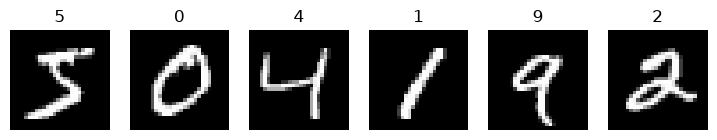

In [5]:
# first six training images, aiming for 5 0 4 1 9 2 
fig, axes = plt.subplots(1, 6, figsize=(9, 1.8))
for k, ax in enumerate(axes):
    ax.imshow(X_train[k].reshape(28, 28), cmap="gray")
    ax.set_title(y_train[k])
    ax.axis("off")
plt.show()

## Task 5 + 6: training and testing

Input layer 784+1, hidden layer 30+1, output layer 10 neurons, quadratic loss.
The progress is printed after every epoch on the validation set; the test set is only used once at the end.

In [6]:
N_HIDDEN = 30
EPOCHS = 30
BATCH_SIZE = 10
ETA = 3.0

net = Network(784, N_HIDDEN, 10, seed=42)
print(f"W1 {net.W1.shape}, W2 {net.W2.shape}")

# before training we should be at 10 % correct
print(f"untrained: {net.evaluate(X_val, y_val)} / {len(y_val)} correct on validation data\n")

history = net.sgd((X_train, Y_train), EPOCHS, BATCH_SIZE, ETA,
                  validation_data=(X_val, y_val))

W1 (30, 785), W2 (10, 31)
untrained: 966 / 10000 correct on validation data

Epoch   1/30   training loss: 0.04673   validation: 9464 / 10000 (94.64 %)
Epoch   2/30   training loss: 0.04110   validation: 9516 / 10000 (95.16 %)
Epoch   3/30   training loss: 0.03575   validation: 9556 / 10000 (95.56 %)
Epoch   4/30   training loss: 0.03503   validation: 9567 / 10000 (95.67 %)
Epoch   5/30   training loss: 0.03309   validation: 9545 / 10000 (95.45 %)
Epoch   6/30   training loss: 0.02849   validation: 9589 / 10000 (95.89 %)
Epoch   7/30   training loss: 0.02741   validation: 9600 / 10000 (96.00 %)
Epoch   8/30   training loss: 0.02889   validation: 9583 / 10000 (95.83 %)
Epoch   9/30   training loss: 0.02607   validation: 9605 / 10000 (96.05 %)
Epoch  10/30   training loss: 0.02755   validation: 9599 / 10000 (95.99 %)
Epoch  11/30   training loss: 0.02538   validation: 9590 / 10000 (95.90 %)
Epoch  12/30   training loss: 0.02576   validation: 9602 / 10000 (96.02 %)
Epoch  13/30   training

In [7]:
correct = net.evaluate(X_test, y_test)
print(f"Test accuracy: {correct} / {len(y_test)} ({100 * correct / len(y_test):.2f} %)")
print(f"Test loss:     {net.loss(X_test, one_hot(y_test)):.5f}")

Test accuracy: 9553 / 10000 (95.53 %)
Test loss:     0.03925


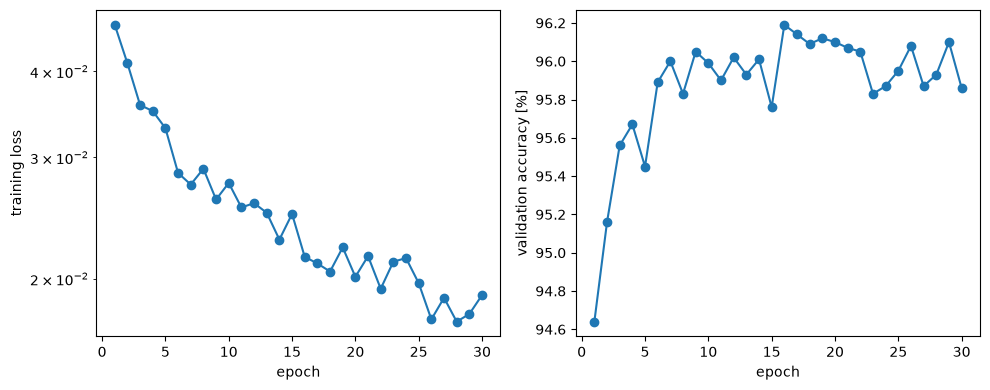

In [8]:
epochs = [h["epoch"] for h in history]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(epochs, [h["train_loss"] for h in history], "o-")
ax1.set_xlabel("epoch")
ax1.set_ylabel("training loss")
ax1.set_yscale("log")
ax2.plot(epochs, [100 * h["val_acc"] for h in history], "o-")
ax2.set_xlabel("epoch")
ax2.set_ylabel("validation accuracy [%]")
fig.tight_layout()
plt.show()

## Task 7: attacking the trained network

During training we use the gradient of the loss w.r.t. the weights. If we instead take the gradient w.r.t. the
input pixels (backprop one layer further), we know how to change an image so that the output changes the way we
want, while the image still looks almost the same to a human.

**1) FGSM** (fast gradient sign method), untargeted:
$$x_{adv} = \mathrm{clip}_{[0,1]}\big(x + \varepsilon \, \mathrm{sign}(\nabla_x C)\big)$$
every pixel changes by at most $\varepsilon$, in the direction that increases the loss.

**2) Targeted attack**: repeated small signed steps that push up the output neuron of a chosen (wrong) digit until
the network predicts that digit. The total change per pixel is kept in $[-\varepsilon, \varepsilon]$.

For the targeted attack the weighted input $z_{target}$ of the output neuron is used instead of the quadratic loss.
Same reason as the learning slowdown of the quadratic loss: when the output sigmoid is saturated (target output
close to 0), $\sigma'(z)$ is almost zero and the loss gradient is basically useless. We tried both, the $z$ version
got a lot more images to flip.

In [9]:
def fgsm(net, X, labels, eps):
    grad = net.input_gradient(X, one_hot(labels))
    X_adv = X + eps * np.sign(grad)
    return np.clip(X_adv, 0.0, 1.0)   # still has to be a valid image


def targeted_attack(net, x, target, eps=0.3, step=0.01, max_iter=200):
    # returns (adversarial image, number of iterations),
    # iterations is None if the network couldn't be fooled within max_iter
    x = x.reshape(1, -1)
    x_adv = x.copy()
    for it in range(1, max_iter + 1):
        grad = net.output_gradient(x_adv, target)
        x_adv = x_adv + step * np.sign(grad)          # gradient ascent on z_target
        x_adv = np.clip(x_adv, x - eps, x + eps)      # stay close to the original
        x_adv = np.clip(x_adv, 0.0, 1.0)
        if net.predict(x_adv)[0] == target:
            return x_adv[0], it
    return x_adv[0], None


def show(ax, img, title):
    ax.imshow(img.reshape(28, 28), cmap="gray", vmin=0, vmax=1)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

### FGSM on the whole test set

eps = 0.00   accuracy on attacked test set:  95.53 %
eps = 0.02   accuracy on attacked test set:  89.66 %
eps = 0.05   accuracy on attacked test set:  82.40 %
eps = 0.08   accuracy on attacked test set:  75.50 %
eps = 0.10   accuracy on attacked test set:  69.90 %
eps = 0.15   accuracy on attacked test set:  54.63 %
eps = 0.20   accuracy on attacked test set:  42.70 %
eps = 0.25   accuracy on attacked test set:  33.52 %
eps = 0.30   accuracy on attacked test set:  26.73 %


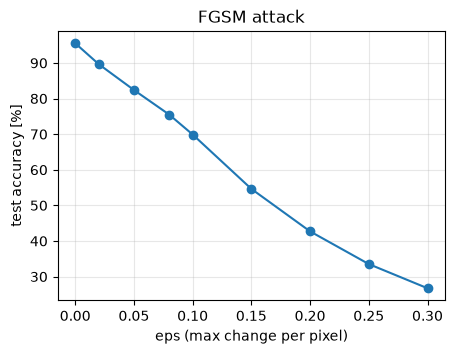

In [10]:
n_test = len(y_test)
eps_values = [0.0, 0.02, 0.05, 0.08, 0.1, 0.15, 0.2, 0.25, 0.3]
accs = []
for eps in eps_values:
    X_adv = fgsm(net, X_test, y_test, eps)
    accs.append(100 * net.evaluate(X_adv, y_test) / n_test)
    print(f"eps = {eps:4.2f}   accuracy on attacked test set: {accs[-1]:6.2f} %")

plt.figure(figsize=(5, 3.5))
plt.plot(eps_values, accs, "o-")
plt.xlabel("eps (max change per pixel)")
plt.ylabel("test accuracy [%]")
plt.title("FGSM attack")
plt.grid(alpha=0.3)
plt.show()

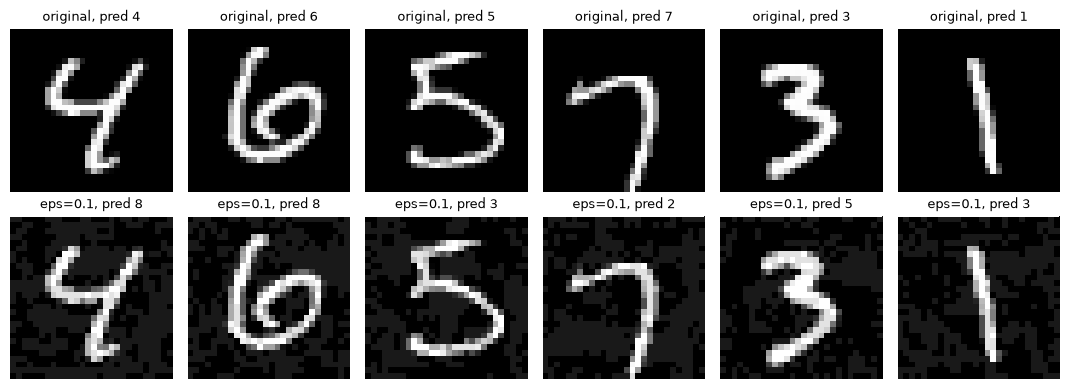

In [11]:
# some examples: original on top, attacked image below
eps = 0.1
X_adv = fgsm(net, X_test, y_test, eps)
pred_clean = net.predict(X_test)
pred_adv = net.predict(X_adv)
# images that were correct before and wrong after the attack
fooled = np.where((pred_clean == y_test) & (pred_adv != y_test))[0][:6]

fig, axes = plt.subplots(2, len(fooled), figsize=(1.8 * len(fooled), 4))
for k, i in enumerate(fooled):
    show(axes[0, k], X_test[i], f"original, pred {pred_clean[i]}")
    show(axes[1, k], X_adv[i], f"eps={eps}, pred {pred_adv[i]}")
fig.tight_layout()
plt.show()

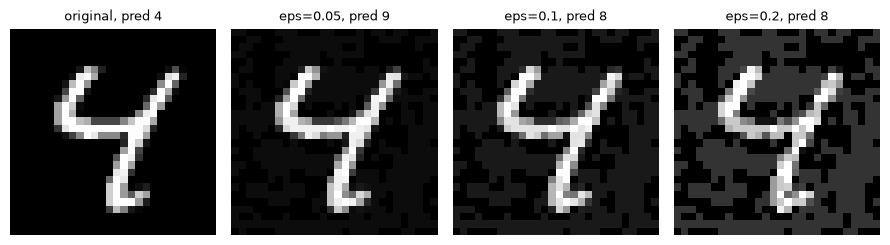

In [12]:
# same test image under increasing FGSM perturbations
i = fooled[0]
x = X_test[i]
fig, axes = plt.subplots(1, 4, figsize=(9, 2.5))
show(axes[0], x, f"original, pred {net.predict(x)[0]}")
for ax, eps in zip(axes[1:], [0.05, 0.1, 0.2]):
    x_adv = fgsm(net, x.reshape(1, -1), y_test[i:i + 1], eps)[0]
    show(ax, x_adv, f"eps={eps}, pred {net.predict(x_adv)[0]}")
fig.tight_layout()
plt.show()

### Targeted attack

Take one test image and try to turn it into every other digit.

test image 0, true label 7, network says 7

target 0: reached after  20 steps, output neuron 0 = 0.582, max pixel change 0.20
target 1: not reached
target 2: reached after  12 steps, output neuron 2 = 0.991, max pixel change 0.12
target 3: reached after   7 steps, output neuron 3 = 0.518, max pixel change 0.07
target 4: not reached
target 5: reached after  12 steps, output neuron 5 = 0.412, max pixel change 0.12
target 6: reached after  78 steps, output neuron 6 = 0.095, max pixel change 0.30
target 8: reached after   8 steps, output neuron 8 = 0.981, max pixel change 0.08
target 9: reached after  13 steps, output neuron 9 = 0.838, max pixel change 0.13


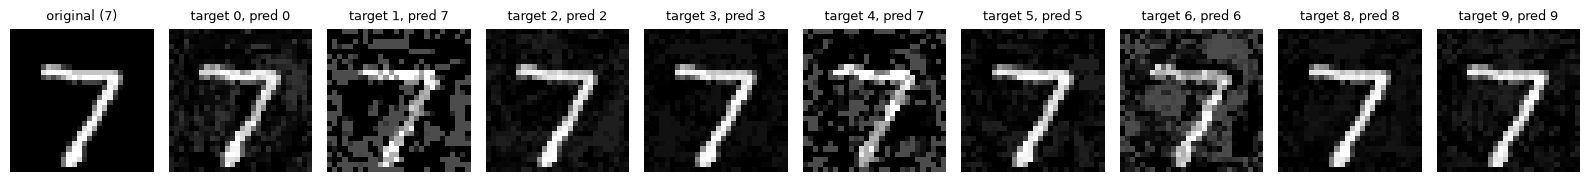

In [13]:
i = 0
x, label = X_test[i], y_test[i]
print(f"test image {i}, true label {label}, network says {net.predict(x)[0]}\n")

fig, axes = plt.subplots(1, 10, figsize=(16, 2.2))
show(axes[0], x, f"original ({label})")
col = 1
for target in range(10):
    if target == label:
        continue
    x_adv, its = targeted_attack(net, x, target)
    out = net.feedforward(x_adv)[0]
    if its is None:
        print(f"target {target}: not reached")
    else:
        print(f"target {target}: reached after {its:3d} steps, "
              f"output neuron {target} = {out[target]:.3f}, "
              f"max pixel change {np.max(np.abs(x_adv - x)):.2f}")
    show(axes[col], x_adv, f"target {target}, pred {net.predict(x_adv)[0]}")
    col += 1
fig.tight_layout()
plt.show()

In [14]:
# success rate on originally correctly classified test images with random wrong targets
rng = np.random.default_rng(0)
correct_idx = np.where(net.predict(X_test) == y_test)[0]
idx = rng.choice(correct_idx, 500, replace=False)
success = 0
for i in idx:
    target = (y_test[i] + rng.integers(1, 10)) % 10
    _, its = targeted_attack(net, X_test[i], target)
    success += its is not None
print(f"success rate on 500 originally correct test images (random wrong target, eps=0.3): "
      f"{100 * success / len(idx):.1f} %")

success rate on 500 originally correct test images (random wrong target, eps=0.3): 91.2 %


# Project 2a: extension

The following cells extend the same `Network` design while keeping row-wise batches and the explicit bias-neuron convention used above.

In [15]:
# Project 2a Tasks 1, 3 and 4: extensible network components

def relu(z):
    return np.maximum(z, 0.0)


def relu_prime(z):
    return (z > 0.0).astype(float)


def tanh_activation(z):
    return np.tanh(z)


def tanh_prime(z):
    a = np.tanh(z)
    return 1.0 - a**2


ACTIVATIONS = {
    "sigmoid": (sigmoid, sigmoid_prime),
    "tanh": (tanh_activation, tanh_prime),
    "relu": (relu, relu_prime),
}


class QuadraticLoss:
    name = "quadratic"

    @staticmethod
    def value(output, target):
        return 0.5 * np.sum((output - target)**2) / len(target)

    @staticmethod
    def gradient(output, target):
        return (output - target) / len(target)


class BinaryCrossEntropy:
    name = "binary cross-entropy"

    @staticmethod
    def value(output, target):
        p = np.clip(output, 1e-12, 1.0 - 1e-12)
        return -np.sum(target * np.log(p) + (1.0 - target) * np.log(1.0 - p)) / len(target)

    @staticmethod
    def gradient(output, target):
        p = np.clip(output, 1e-12, 1.0 - 1e-12)
        return (p - target) / (p * (1.0 - p) * len(target))


LOSSES = {
    "quadratic": QuadraticLoss,
    "binary_cross_entropy": BinaryCrossEntropy,
}


def activation_pair(spec):
    return ACTIVATIONS[spec] if isinstance(spec, str) else spec


class Network:
    def __init__(self, n_in, n_hidden=None, n_out=None, seed=None,
                 activations="sigmoid", loss="quadratic", decoder=None):
        # Old interface: Network(784, 30, 10). New interface: Network([784, 64, 32, 10]).
        if n_out is None and not np.isscalar(n_in):
            self.sizes = list(n_in)
        else:
            self.sizes = [n_in, n_hidden, n_out]
        if len(self.sizes) < 2:
            raise ValueError("sizes must include input and output layers")

        self.n_in = self.sizes[0]
        self.n_hidden = self.sizes[1:-1]
        self.n_out = self.sizes[-1]
        self.rng = np.random.default_rng(seed)

        n_weight_layers = len(self.sizes) - 1
        if isinstance(activations, str) or (
                isinstance(activations, tuple) and callable(activations[0])):
            activations = [activations] * n_weight_layers
        if len(activations) != n_weight_layers:
            raise ValueError("one activation is required for every non-input layer")
        self.activations = [activation_pair(a) for a in activations]
        self.loss_function = LOSSES[loss] if isinstance(loss, str) else loss
        self.decoder = decoder

        self.weights = [
            self.rng.normal(0.0, 1.0 / np.sqrt(n_source + 1),
                            (n_target, n_source + 1))
            for n_source, n_target in zip(self.sizes[:-1], self.sizes[1:])
        ]

    def _forward(self, X):
        layer_outputs = [np.atleast_2d(X)]
        weighted_inputs = []
        for W, (function, _) in zip(self.weights, self.activations):
            z = add_bias(layer_outputs[-1]) @ W.T
            weighted_inputs.append(z)
            layer_outputs.append(function(z))
        return layer_outputs, weighted_inputs

    def feedforward(self, X):
        return self._forward(X)[0][-1]

    def predict(self, X):
        output = self.feedforward(X)
        if self.decoder is not None:
            return self.decoder(output)
        return np.argmax(output, axis=1)

    def evaluate(self, X, labels):
        return int(np.sum(self.predict(X) == labels))

    def loss(self, X, Y):
        return self.loss_function.value(self.feedforward(X), Y)

    def backprop(self, X, Y):
        layer_outputs, weighted_inputs = self._forward(X)
        gradients = [None] * len(self.weights)

        delta = self.loss_function.gradient(layer_outputs[-1], Y)
        delta *= self.activations[-1][1](weighted_inputs[-1])

        for layer in range(len(self.weights) - 1, -1, -1):
            gradients[layer] = delta.T @ add_bias(layer_outputs[layer])
            if layer > 0:
                delta = (delta @ self.weights[layer][:, :-1])
                delta *= self.activations[layer - 1][1](weighted_inputs[layer - 1])
        return gradients

    def input_gradient(self, X, Y):
        layer_outputs, weighted_inputs = self._forward(X)
        delta = self.loss_function.gradient(layer_outputs[-1], np.atleast_2d(Y))
        delta *= self.activations[-1][1](weighted_inputs[-1])
        for layer in range(len(self.weights) - 1, 0, -1):
            delta = (delta @ self.weights[layer][:, :-1])
            delta *= self.activations[layer - 1][1](weighted_inputs[layer - 1])
        return delta @ self.weights[0][:, :-1]

    def output_gradient(self, X, k):
        _, weighted_inputs = self._forward(X)
        delta = np.zeros((np.atleast_2d(X).shape[0], self.n_out))
        delta[:, k] = 1.0
        for layer in range(len(self.weights) - 1, 0, -1):
            delta = (delta @ self.weights[layer][:, :-1])
            delta *= self.activations[layer - 1][1](weighted_inputs[layer - 1])
        return delta @ self.weights[0][:, :-1]

    def sgd(self, training_data, epochs, batch_size, eta, validation_data=None):
        X, Y = training_data
        history = []
        for epoch in range(1, epochs + 1):
            order = self.rng.permutation(len(X))
            for start in range(0, len(X), batch_size):
                idx = order[start:start + batch_size]
                gradients = self.backprop(X[idx], Y[idx])
                for layer in range(len(self.weights)):
                    self.weights[layer] -= eta * gradients[layer]

            record = {"epoch": epoch, "train_loss": self.loss(X, Y)}
            message = f"Epoch {epoch:3d}/{epochs}   training loss: {record['train_loss']:.5f}"
            if validation_data is not None:
                Xv, yv = validation_data
                correct = self.evaluate(Xv, yv)
                record["val_acc"] = correct / len(yv)
                message += f"   validation: {correct} / {len(yv)} ({100 * record['val_acc']:.2f} %)"
            print(message)
            history.append(record)
        return history


In [16]:
# Gradient check with two hidden layers, mixed activations and a non-quadratic loss.
rng_ext = np.random.default_rng(0)
tiny = Network([5, 4, 3, 2], seed=0,
               activations=["tanh", "sigmoid", "sigmoid"],
               loss="binary_cross_entropy")
X_ext = rng_ext.normal(size=(4, 5))
Y_ext = rng_ext.integers(0, 2, size=(4, 2)).astype(float)
analytical = tiny.backprop(X_ext, Y_ext)

h = 1e-6
max_difference = 0.0
for W, gradient in zip(tiny.weights, analytical):
    numerical = np.zeros_like(W)
    for i in range(W.shape[0]):
        for j in range(W.shape[1]):
            old = W[i, j]
            W[i, j] = old + h
            plus = tiny.loss(X_ext, Y_ext)
            W[i, j] = old - h
            minus = tiny.loss(X_ext, Y_ext)
            W[i, j] = old
            numerical[i, j] = (plus - minus) / (2 * h)
    max_difference = max(max_difference, np.max(np.abs(numerical - gradient)))

print("weight shapes:", [W.shape for W in tiny.weights])
print(f"deep-network BCE gradient check: {max_difference:.2e}")

deep_example = Network([784, 64, 32, 10], seed=1,
                       activations=["relu", "relu", "sigmoid"],
                       loss="binary_cross_entropy")
print("example architecture:", deep_example.sizes)
print("activations: ReLU, ReLU, sigmoid; loss: binary cross-entropy")


weight shapes: [(4, 6), (3, 5), (2, 4)]
deep-network BCE gradient check: 2.75e-10
example architecture: [784, 64, 32, 10]
activations: ReLU, ReLU, sigmoid; loss: binary cross-entropy


## Project 2a Task 2: four bit outputs versus ten one-hot outputs

Digits are encoded by four bits in most-significant-bit-first order. At prediction time the raw four outputs are matched to the nearest of the ten valid digit codes, so invalid bit patterns 10-15 cannot be returned. Both networks below use the same hidden layer, sigmoid activations, quadratic loss, seed, mini-batch size, learning rate and epoch budget. This isolates the effect of the output representation.

In [17]:
BIT_WEIGHTS = np.array([8, 4, 2, 1])
BIT_CODES = ((np.arange(10)[:, None] & BIT_WEIGHTS) > 0).astype(float)


def bit_targets(labels):
    return BIT_CODES[np.asarray(labels)]


def decode_bits(output):
    squared_distance = np.sum((output[:, None, :] - BIT_CODES[None, :, :])**2, axis=2)
    return np.argmin(squared_distance, axis=1)


COMPARE_EPOCHS = 15
COMPARE_BATCH_SIZE = 20
COMPARE_ETA = 3.0

onehot_net = Network([784, 30, 10], seed=42,
                     activations="sigmoid", loss="quadratic")
bit_net = Network([784, 30, 4], seed=42,
                  activations="sigmoid", loss="quadratic", decoder=decode_bits)

print("Training 10-output network")
onehot_history = onehot_net.sgd(
    (X_train, Y_train), COMPARE_EPOCHS, COMPARE_BATCH_SIZE, COMPARE_ETA,
    validation_data=(X_val, y_val))

print("\nTraining 4-output network")
bit_history = bit_net.sgd(
    (X_train, bit_targets(y_train)), COMPARE_EPOCHS, COMPARE_BATCH_SIZE, COMPARE_ETA,
    validation_data=(X_val, y_val))


def parameter_count(model):
    return sum(W.size for W in model.weights)


print("\nrepresentation   parameters   validation accuracy   test accuracy")
for name, model in [("10 one-hot", onehot_net), ("4 bit", bit_net)]:
    validation_accuracy = model.evaluate(X_val, y_val) / len(y_val)
    test_accuracy = model.evaluate(X_test, y_test) / len(y_test)
    print(f"{name:14s} {parameter_count(model):10d} "
          f"{100 * validation_accuracy:18.2f}% {100 * test_accuracy:14.2f}%")


Training 10-output network
Epoch   1/15   training loss: 0.05479   validation: 9392 / 10000 (93.92 %)
Epoch   2/15   training loss: 0.04620   validation: 9469 / 10000 (94.69 %)
Epoch   3/15   training loss: 0.03749   validation: 9563 / 10000 (95.63 %)
Epoch   4/15   training loss: 0.03639   validation: 9559 / 10000 (95.59 %)
Epoch   5/15   training loss: 0.03387   validation: 9599 / 10000 (95.99 %)
Epoch   6/15   training loss: 0.02967   validation: 9627 / 10000 (96.27 %)
Epoch   7/15   training loss: 0.02846   validation: 9630 / 10000 (96.30 %)
Epoch   8/15   training loss: 0.02735   validation: 9630 / 10000 (96.30 %)
Epoch   9/15   training loss: 0.02757   validation: 9615 / 10000 (96.15 %)
Epoch  10/15   training loss: 0.02517   validation: 9638 / 10000 (96.38 %)
Epoch  11/15   training loss: 0.02443   validation: 9632 / 10000 (96.32 %)
Epoch  12/15   training loss: 0.02376   validation: 9635 / 10000 (96.35 %)
Epoch  13/15   training loss: 0.02427   validation: 9641 / 10000 (96.41 %

## Project 2a Task 5: adversarial data augmentation

We use the trained ten-output model to make FGSM examples from 10,000 randomly selected training images at $\varepsilon=0.1$. A new model is trained from scratch on the 50,000 clean images plus these 10,000 attacked images. The final comparison uses a white-box FGSM attack generated separately against each tested model; clean test accuracy is reported as well.

Epoch   1/15   training loss: 0.06204   validation: 9366 / 10000 (93.66 %)
Epoch   2/15   training loss: 0.05205   validation: 9447 / 10000 (94.47 %)
Epoch   3/15   training loss: 0.04477   validation: 9527 / 10000 (95.27 %)
Epoch   4/15   training loss: 0.04173   validation: 9542 / 10000 (95.42 %)
Epoch   5/15   training loss: 0.03790   validation: 9566 / 10000 (95.66 %)
Epoch   6/15   training loss: 0.03817   validation: 9549 / 10000 (95.49 %)
Epoch   7/15   training loss: 0.03372   validation: 9568 / 10000 (95.68 %)
Epoch   8/15   training loss: 0.03623   validation: 9528 / 10000 (95.28 %)
Epoch   9/15   training loss: 0.03019   validation: 9599 / 10000 (95.99 %)
Epoch  10/15   training loss: 0.03039   validation: 9602 / 10000 (96.02 %)
Epoch  11/15   training loss: 0.03677   validation: 9551 / 10000 (95.51 %)
Epoch  12/15   training loss: 0.02659   validation: 9603 / 10000 (96.03 %)
Epoch  13/15   training loss: 0.02653   validation: 9599 / 10000 (95.99 %)
Epoch  14/15   training l

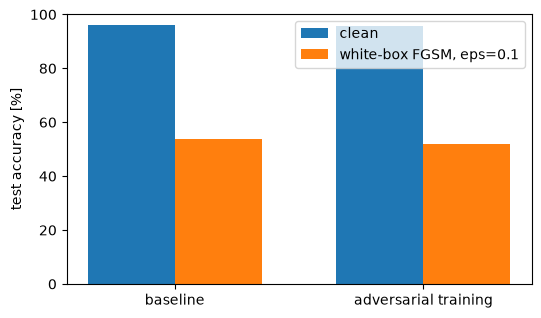

In [18]:
def fgsm_from_targets(model, X, Y, eps, batch_size=1000):
    attacked = np.empty_like(X)
    for start in range(0, len(X), batch_size):
        stop = min(start + batch_size, len(X))
        gradient = model.input_gradient(X[start:stop], Y[start:stop])
        attacked[start:stop] = np.clip(
            X[start:stop] + eps * np.sign(gradient), 0.0, 1.0)
    return attacked


ATTACK_EPS = 0.1
ADVERSARIAL_TRAINING_SAMPLES = 10000
ROBUST_EPOCHS = 15

augmentation_rng = np.random.default_rng(123)
augmentation_index = augmentation_rng.choice(
    len(X_train), ADVERSARIAL_TRAINING_SAMPLES, replace=False)
X_train_attacked = fgsm_from_targets(
    onehot_net, X_train[augmentation_index], Y_train[augmentation_index], ATTACK_EPS)

X_train_augmented = np.vstack([X_train, X_train_attacked])
Y_train_augmented = np.vstack([Y_train, Y_train[augmentation_index]])

robust_net = Network([784, 30, 10], seed=42,
                     activations="sigmoid", loss="quadratic")
robust_history = robust_net.sgd(
    (X_train_augmented, Y_train_augmented), ROBUST_EPOCHS,
    COMPARE_BATCH_SIZE, COMPARE_ETA,
    validation_data=(X_val, y_val))

Y_test_onehot = one_hot(y_test)
X_test_attacked_baseline = fgsm_from_targets(
    onehot_net, X_test, Y_test_onehot, ATTACK_EPS)
X_test_attacked_robust = fgsm_from_targets(
    robust_net, X_test, Y_test_onehot, ATTACK_EPS)

clean_baseline = onehot_net.evaluate(X_test, y_test) / len(y_test)
attacked_baseline = onehot_net.evaluate(X_test_attacked_baseline, y_test) / len(y_test)
clean_robust = robust_net.evaluate(X_test, y_test) / len(y_test)
attacked_robust = robust_net.evaluate(X_test_attacked_robust, y_test) / len(y_test)

print("model          clean test accuracy   white-box FGSM accuracy")
print(f"baseline       {100 * clean_baseline:18.2f}% {100 * attacked_baseline:24.2f}%")
print(f"adversarial    {100 * clean_robust:18.2f}% {100 * attacked_robust:24.2f}%")

x_position = np.arange(2)
width = 0.35
plt.figure(figsize=(6, 3.5))
plt.bar(x_position - width / 2,
        [100 * clean_baseline, 100 * clean_robust], width, label="clean")
plt.bar(x_position + width / 2,
        [100 * attacked_baseline, 100 * attacked_robust], width,
        label=f"white-box FGSM, eps={ATTACK_EPS}")
plt.xticks(x_position, ["baseline", "adversarial training"])
plt.ylabel("test accuracy [%]")
plt.ylim(0, 100)
plt.legend()
plt.show()


Epoch   1/10   training loss: 0.06037   validation: 9623 / 10000 (96.23 %)
Epoch   2/10   training loss: 0.05543   validation: 9634 / 10000 (96.34 %)
Epoch   3/10   training loss: 0.05179   validation: 9655 / 10000 (96.55 %)
Epoch   4/10   training loss: 0.04945   validation: 9656 / 10000 (96.56 %)
Epoch   5/10   training loss: 0.04742   validation: 9647 / 10000 (96.47 %)
Epoch   6/10   training loss: 0.04466   validation: 9658 / 10000 (96.58 %)
Epoch   7/10   training loss: 0.04269   validation: 9651 / 10000 (96.51 %)
Epoch   8/10   training loss: 0.04116   validation: 9664 / 10000 (96.64 %)
Epoch   9/10   training loss: 0.03929   validation: 9652 / 10000 (96.52 %)
Epoch  10/10   training loss: 0.03799   validation: 9650 / 10000 (96.50 %)
clean 0.9585
fgsm 0.7009

model          clean test accuracy   white-box FGSM accuracy
baseline                    96.01%                    53.75%
fine-tuned                  95.85%                    70.09%


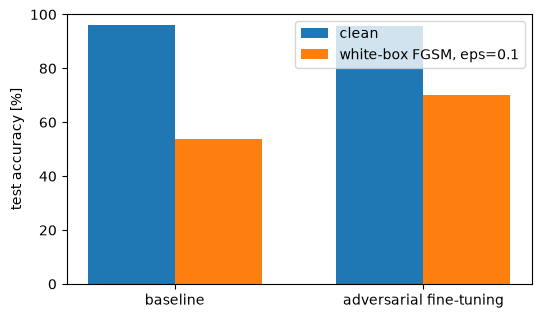

In [19]:
robust_tuned = Network([784, 30, 10], seed=42,
                       activations="sigmoid", loss="quadratic")
robust_tuned.weights = [W.copy() for W in onehot_net.weights]
robust_tuned_history = robust_tuned.sgd(
    (X_train_augmented, Y_train_augmented), 10,
    COMPARE_BATCH_SIZE, 1.0,
    validation_data=(X_val, y_val))
X_test_attacked_tuned = fgsm_from_targets(
    robust_tuned, X_test, Y_test_onehot, ATTACK_EPS)
print("clean", robust_tuned.evaluate(X_test, y_test) / len(y_test))
print("fgsm", robust_tuned.evaluate(X_test_attacked_tuned, y_test) / len(y_test))

clean_tuned = robust_tuned.evaluate(X_test, y_test) / len(y_test)
attacked_tuned = robust_tuned.evaluate(X_test_attacked_tuned, y_test) / len(y_test)
print("\nmodel          clean test accuracy   white-box FGSM accuracy")
print(f"baseline       {100 * clean_baseline:18.2f}% {100 * attacked_baseline:24.2f}%")
print(f"fine-tuned     {100 * clean_tuned:18.2f}% {100 * attacked_tuned:24.2f}%")

plt.figure(figsize=(6, 3.5))
plt.bar(x_position - width / 2,
        [100 * clean_baseline, 100 * clean_tuned], width, label="clean")
plt.bar(x_position + width / 2,
        [100 * attacked_baseline, 100 * attacked_tuned], width,
        label=f"white-box FGSM, eps={ATTACK_EPS}")
plt.xticks(x_position, ["baseline", "adversarial fine-tuning"])
plt.ylabel("test accuracy [%]")
plt.ylim(0, 100)
plt.legend()
plt.show()

## Extensibility discussion

The data layout, explicit bias-neuron convention, SGD loop and attack idea were reusable. The parts tied to exactly one hidden layer had to be rewritten:

- W1 and W2 became a list of weight matrices created from a layer-size list.
- Forward propagation, backpropagation, input gradients and parameter updates became loops over layers.
- Each non-input layer now receives an activation/derivative pair, and the output loss supplies both its value and derivative.
- Classification is separated from raw network output through a decoder; this is what lets the same class support one-hot and four-bit targets.

The gradient check above verifies the rewritten backpropagation for two hidden layers, mixed activations and binary cross-entropy. Task 5 then reuses the generalized input_gradient method without changing the attack code.

## Project 2a findings

- The generalized four-layer gradient check differs from central finite differences by only $2.75\times 10^{-10}$. This supports the rewritten loop-based backpropagation with mixed activations and binary cross-entropy.
- With the same 15-epoch budget, the ten-output network used 23,860 parameters and reached 96.01% test accuracy. The four-bit network used 23,674 parameters (186 fewer, about 0.78%) and reached 93.82%. The compact code therefore saved few parameters because most weights are in the input-to-hidden matrix, while losing 2.19 percentage points of test accuracy.
- Simply training a fresh network on the mixed clean/adversarial set did not improve this white-box attack (52.08% versus the 53.75% baseline). Starting from the clean model and adversarially fine-tuning for 10 epochs at learning rate 1.0 raised white-box FGSM accuracy to 70.09%, while clean test accuracy changed only from 96.01% to 95.85%.

The comparison is attack-specific: a defense should also be tested against other perturbation sizes and attacks before making a general robustness claim.